In [1]:
import sksurv #scikit-survival
import pandas as pd
import numpy as np
import sys
import os


sys.path.append(os.path.abspath("../../"))
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.Preprocessing import Preprocessor
from src.utils.plots import Plots
%load_ext autoreload
%autoreload 2

In [2]:
pp = Preprocessor()
plots = Plots()
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_keep = pp.clean_columns_dataset(df_clinical_data)

    

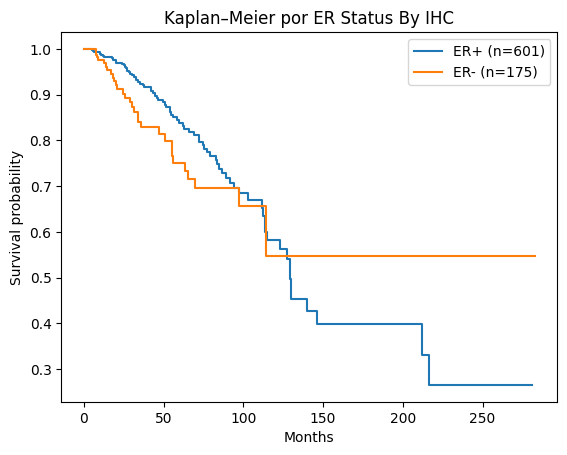

Log-rank: chi2=1.607, p=0.205


In [3]:

km_df = plots.plot_kaplan_meier_binary(df_clinical_keep, time_col="Overall Survival (Months)", status_col="Overall Survival Status",marker_col="ER Status By IHC")

In [4]:
list_df = pp.total_type_len_type_cancer(df_clinical_keep)
df_clinical_keep["Tumor-Cancer"] = list_df
df_mRNA_transformed = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")



Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)


In [30]:
ESR1 = df_mRNA_transformed[df_mRNA_transformed["Hugo_Symbol"] == "ESR1"]
AURKA = df_mRNA_transformed[df_mRNA_transformed["Hugo_Symbol"] == "AURKA"]

"""
for i, row in enumerate(ESR1):
    print(row)
    """
treshold_AURKA = np.median(AURKA.iloc[:, 2:])
print(treshold_AURKA)
"""
for item in AURKA.iloc[:, 2:]:
    print(item)
"""
#x = [x for x in AURKA.iloc[:, 2:].values if x > treshold_AURKA ]

AURKA.iloc[:, 2:].values

low_bound = list()
for item in AURKA.iloc[:, 2:].values:
    if item <= treshold_AURKA:
        low_bound.append(item)
    else:
        low_bound.append("mayor")

    

419.1242


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
df_merged = pp.merge_datasets(df_clinical_keep, df_mRNA_transformed)
df_merged["ER Status By IHC"]



False

In [7]:
binary_groups_df = df_merged.loc[
    df_merged["Binary ER group"].isin([0, 1]),
    ["Binary ER group"] +list(df_merged.columns[1:20441])
]

binary_groups_df["Binary ER group"].unique()

array([1, 0])

In [8]:
binary_reduce_df = pp.elimnation_zeros(binary_groups_df, "Binary ER group")

Max of zeros per row in the dataset: 775
Avg of zeros per row in the dataset: 110.59877690802348
Median of zeros per row in the dataset: 0.0
Min of zeros per row in the dataset: 0
After the 0 elimination: 16264


In [40]:
print(f"Samples: {binary_reduce_df.shape[0]}, Genes: {binary_reduce_df.shape[1]}")

Samples: 775, Genes: 16264


In [41]:
results_df, design, _ = pp.initialize_limma(binary_reduce_df, "Binary ER group")
results_df.rename(columns={"column0" : "Binary 0",
                           "column1": "Binary 1"})

,Binary 0,Binary 1,AveExpr,F,pvalue,adj_pvalue
10190,7.587871,7.643881,7.631233,58628.740884,0.000000e+00,0.000000e+00
10191,8.912371,8.022297,8.223281,20972.390177,0.000000e+00,0.000000e+00
56,9.820627,11.004093,10.736859,46571.716726,0.000000e+00,0.000000e+00
10194,2.864254,3.434416,3.305669,3742.256511,0.000000e+00,0.000000e+00
58,7.734712,8.049891,7.978722,19519.111418,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
4988,2.404297,2.061032,2.138543,419.623971,5.749432e-183,5.750846e-183
17494,1.954852,2.102671,2.069292,376.615675,2.740884e-164,2.741389e-164
5630,1.656050,1.954234,1.886902,367.969250,1.559500e-160,1.559692e-160
16977,1.783533,3.149988,2.841434,359.632269,6.511637e-157,6.512038e-157
